# 🌿 Carbon CO₂ Emission Prediction
## Complete Machine Learning Pipeline

---

**Dataset:** Global Energy & CO₂ Statistics — 55,440 rows × 11 columns

**Target:** `CO2_emission` (Million Tonnes)

**Models:** Random Forest | Gradient Boosting | Ridge | Linear Regression

**Metrics:** R² | RMSE | MAE | Within-10% Accuracy

## 📦 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [2]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)


In [3]:
# ── Dark green plot theme ─────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor':  '#f6fff8',
    'axes.edgecolor':   '#2d6a4f', 'axes.labelcolor': '#1b4332',
    'text.color':       '#1b4332', 'xtick.color':     '#2d6a4f',
    'ytick.color':      '#2d6a4f', 'grid.color':      '#2d4a3e',
    'grid.linewidth':    0.5,      'axes.titlecolor': '#2d6a4f',
    'figure.dpi':       120,
})
G = ['#2d6a4f','#40916c','#52b788','#74c69d','#95d5b2','#b7e4c7']

print("✔ Libraries imported!")

✔ Libraries imported!


## 📂 2. Load & Explore Dataset

In [4]:
df_raw = pd.read_csv("carbon_.csv")
if "Unnamed: 0" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Unnamed: 0"])

print(f"Shape  : {df_raw.shape}")
df_raw.head(10)

Shape  : (55440, 10)


,Country,Energy_type,Year,Energy_consumption,Energy_production,GDP,Population,Energy_intensity_per_capita,Energy_intensity_by_GDP,CO2_emission
0,World,all_energy_types,1980,292.8998,296.3372,27770.9103,4298126.5220,68.1459,10.5470,4946.6271
1,World,coal,1980,78.6561,80.1142,27770.9103,4298126.5220,68.1459,10.5470,1409.7902
2,World,natural_gas,1980,53.8652,54.7610,27770.9103,4298126.5220,68.1459,10.5470,1081.5934
3,World,petroleum_n_other_liquids,1980,132.0640,133.1111,27770.9103,4298126.5220,68.1459,10.5470,2455.2436
4,World,nuclear,1980,7.5757,7.5757,27770.9103,4298126.5220,68.1459,10.5470,0.0000
5,World,renewables_n_other,1980,20.7023,20.7752,27770.9103,4298126.5220,68.1459,10.5470,0.0000
6,Afghanistan,all_energy_types,1980,0.0266,0.0726,NaN,13356.5000,1.9903,0.0000,NaN
7,Afghanistan,coal,1980,0.0025,0.0024,NaN,13356.5000,1.9903,0.0000,NaN
8,Afghanistan,natural_gas,1980,0.0021,0.0628,NaN,13356.5000,1.9903,0.0000,NaN
9,Afghanistan,petroleum_n_other_liquids,1980,0.0146,0.0000,NaN,13356.5000,1.9903,0.0000,NaN


In [5]:
# Column types & missing values
info = pd.DataFrame({
    "dtype":   df_raw.dtypes,
    "non_null":df_raw.notna().sum(),
    "null":    df_raw.isna().sum(),
})
print(info.to_string())

                               dtype  non_null   null
Country                       object     55440      0
Energy_type                   object     55440      0
Year                           int64     55440      0
Energy_consumption           float64     44287  11153
Energy_production            float64     44289  11151
GDP                          float64     40026  15414
Population                   float64     46014   9426
Energy_intensity_per_capita  float64     50358   5082
Energy_intensity_by_GDP      float64     50358   5082
CO2_emission                 float64     51614   3826


In [6]:
# Statistical summary
print(f"Countries   : {df_raw['Country'].nunique()}")
print(f"Energy types: {df_raw['Energy_type'].nunique()}")
print(f"Year range  : {df_raw['Year'].min()} – {df_raw['Year'].max()}")
print(f"\nEnergy types: {list(df_raw['Energy_type'].unique())}")
df_raw.describe().T

Countries   : 231
Energy types: 6
Year range  : 1980 – 2019

Energy types: ['all_energy_types', 'coal', 'natural_gas', 'petroleum_n_other_liquids', 'nuclear', 'renewables_n_other']


,count,mean,std,min,25%,50%,75%,max
Year,55440.0000,1999.5000,11.5435,1980.0000,1989.7500,1999.5000,2009.2500,2019.0000
Energy_consumption,44287.0000,1.5378,15.4566,-0.1634,0.0000,0.0184,0.2094,601.0405
Energy_production,44289.0000,1.5327,15.3036,-0.0000,0.0000,0.0005,0.1125,611.5090
GDP,40026.0000,827.1441,5981.7031,0.1250,9.7378,47.7571,263.6871,127690.2471
Population,46014.0000,62630.2048,456208.8203,11.4710,1141.9500,6157.6800,20042.9000,7714631.0640
Energy_intensity_per_capita,50358.0000,71.8989,113.7287,0.0000,3.7999,29.7793,95.5236,1139.3206
Energy_intensity_by_GDP,50358.0000,3.6951,4.5907,0.0000,0.8994,2.9876,4.9695,166.9136
CO2_emission,51614.0000,78.8001,902.2215,-0.0051,0.0000,0.0000,4.3188,35584.9335


## 🔍 3. Exploratory Data Analysis (EDA)

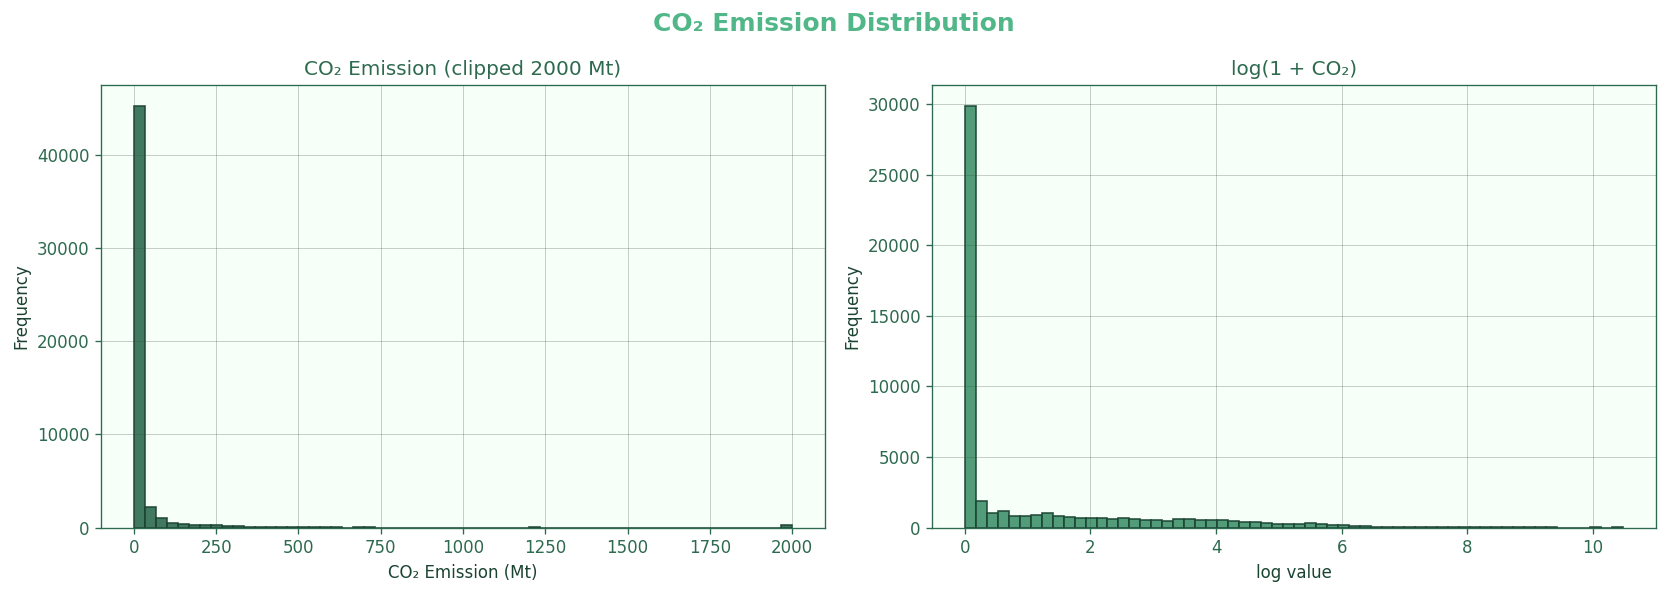

Min:-0.01  Max:35584.93  Mean:78.80  Median:0.00


In [7]:
# CO2 Emission Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CO₂ Emission Distribution", fontsize=15, fontweight='bold', color='#52b788')

target_clean = df_raw['CO2_emission'].dropna()
axes[0].hist(target_clean.clip(0, 2000), bins=60, color=G[0], edgecolor='#1b4332', alpha=0.9)
axes[0].set_title("CO₂ Emission (clipped 2000 Mt)")
axes[0].set_xlabel("CO₂ Emission (Mt)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.log1p(target_clean.clip(0)), bins=60, color=G[1], edgecolor='#1b4332', alpha=0.9)
axes[1].set_title("log(1 + CO₂)")
axes[1].set_xlabel("log value")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Min:{target_clean.min():.2f}  Max:{target_clean.max():.2f}  "
      f"Mean:{target_clean.mean():.2f}  Median:{target_clean.median():.2f}")

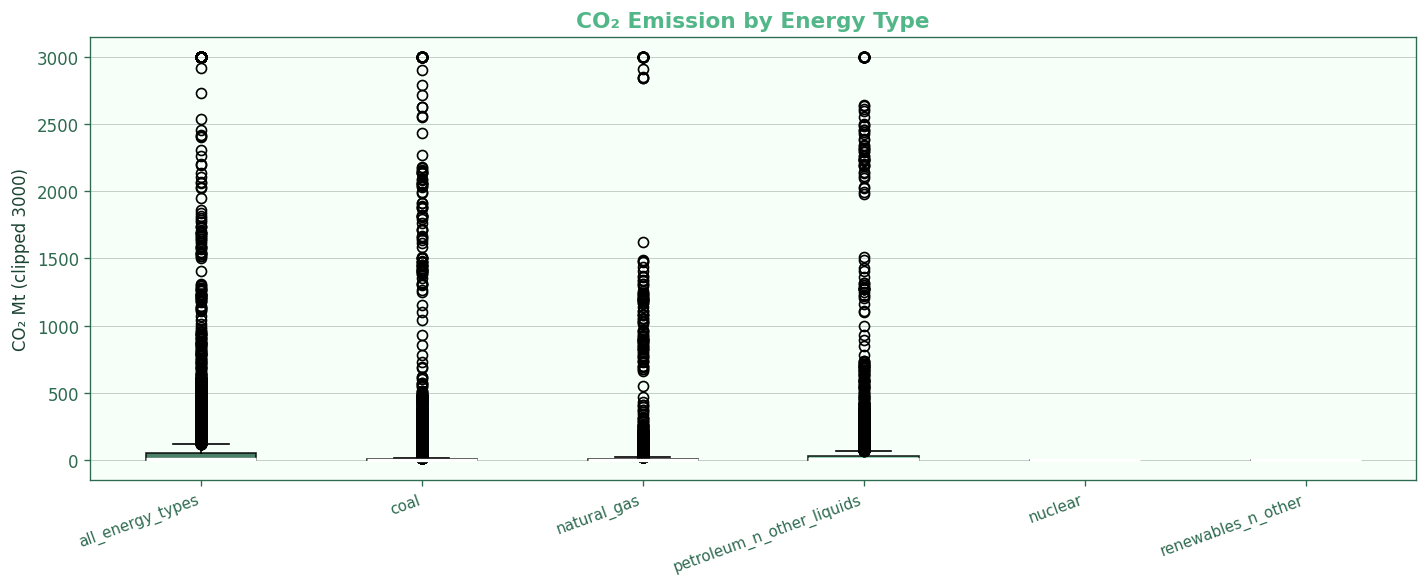

In [8]:
# CO2 by Energy Type – Boxplot
df_plot = df_raw.dropna(subset=['CO2_emission'])
fig, ax  = plt.subplots(figsize=(12, 5))

energy_list = list(df_raw['Energy_type'].unique())
data_by_type = [df_plot[df_plot['Energy_type']==et]['CO2_emission'].clip(0,3000).values
                for et in energy_list]
bp = ax.boxplot(data_by_type, patch_artist=True,
                medianprops=dict(color='#ffffff', linewidth=2))
for patch, color in zip(bp['boxes'], G):
    patch.set_facecolor(color); patch.set_alpha(0.85)

ax.set_xticklabels(energy_list, rotation=20, ha='right', fontsize=9)
ax.set_ylabel("CO₂ Mt (clipped 3000)"); ax.grid(True, axis='y', alpha=0.3)
ax.set_title("CO₂ Emission by Energy Type", fontsize=13, fontweight='bold', color='#52b788')
plt.tight_layout(); plt.show()

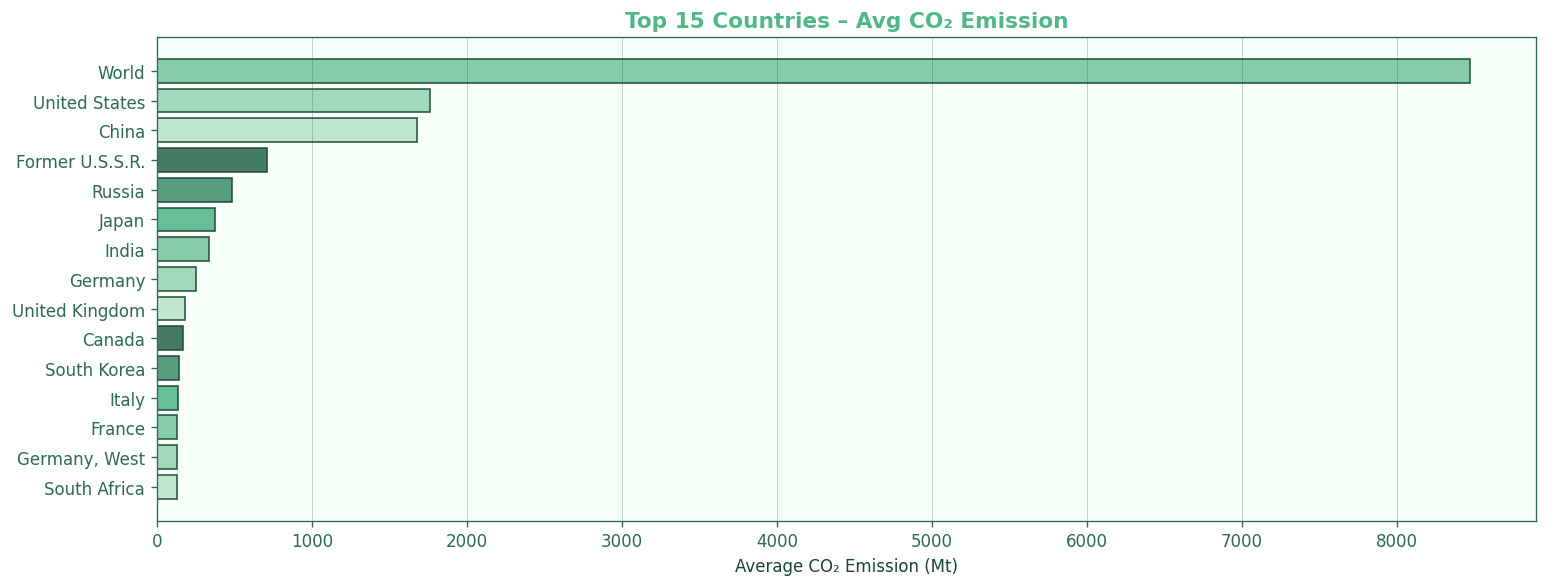

In [9]:
# Top 15 Countries by Avg CO2
top = df_plot.groupby('Country')['CO2_emission'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(top.index[::-1], top.values[::-1], color=G[::-1]*3, edgecolor='#1b4332', alpha=0.88)
ax.set_xlabel("Average CO₂ Emission (Mt)")
ax.set_title("Top 15 Countries – Avg CO₂ Emission", fontsize=13, fontweight='bold', color='#52b788')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

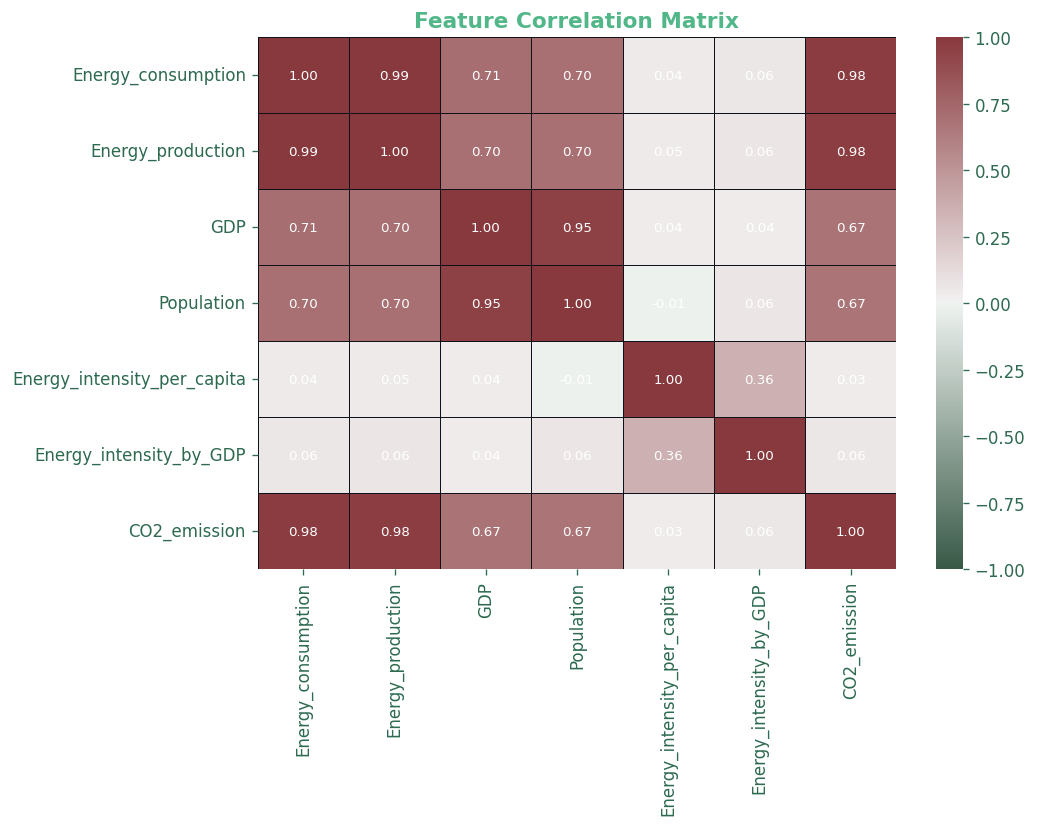

In [11]:
# Correlation Heatmap
num_cols = ['Energy_consumption','Energy_production','GDP','Population',
            'Energy_intensity_per_capita','Energy_intensity_by_GDP','CO2_emission']
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
cmap = sns.diverging_palette(145, 10, s=50, l=35, as_cmap=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap=cmap, ax=ax,
            linewidths=0.5, linecolor='#0e1117', vmin=-1, vmax=1,
            annot_kws={"size":8, "color":"white"})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight='bold', color='#52b788')
plt.tight_layout(); plt.show()

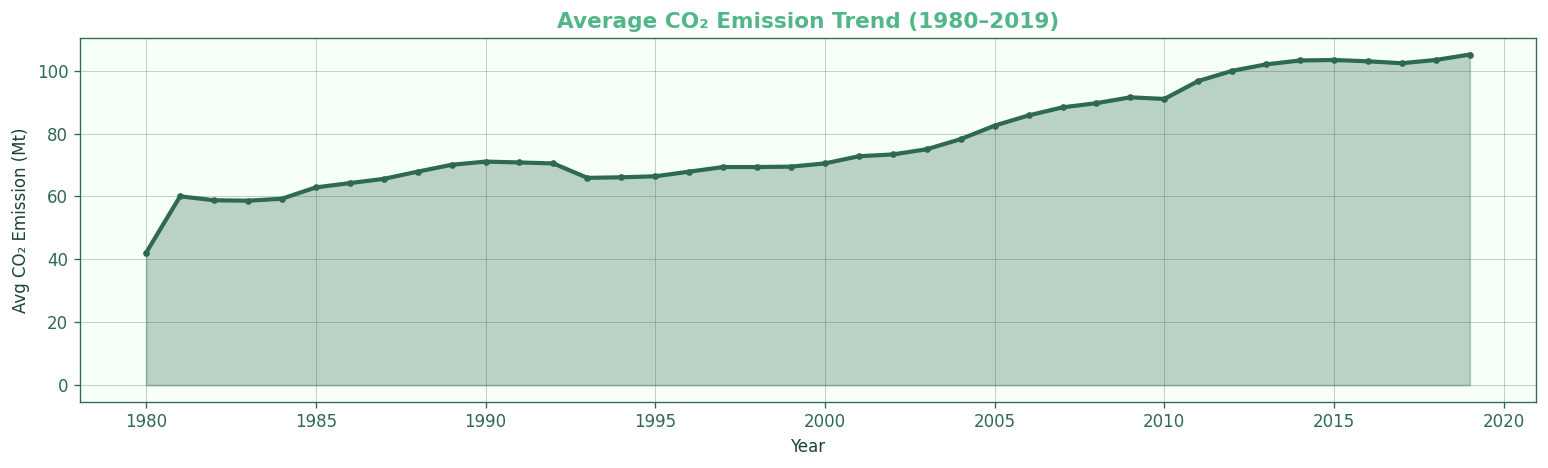

In [12]:
# CO2 Trend Over Years
yearly = df_plot.groupby('Year')['CO2_emission'].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(yearly.index, yearly.values, alpha=0.3, color=G[0])
ax.plot(yearly.index, yearly.values, color=G[0], linewidth=2.5, marker='o', markersize=3)
ax.set_title("Average CO₂ Emission Trend (1980–2019)", fontsize=13, fontweight='bold', color='#52b788')
ax.set_xlabel("Year"); ax.set_ylabel("Avg CO₂ Emission (Mt)")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 🛠️ 4. Data Preprocessing

In [13]:
TARGET = "CO2_emission"

# Drop rows where target is missing
df = df_raw.dropna(subset=[TARGET]).copy()
print(f"Rows after target dropna : {len(df):,}  (removed {len(df_raw)-len(df):,})")

# Fill numeric NaNs with column median
NUMERIC_COLS = ['Energy_consumption','Energy_production','GDP',
                'Population','Energy_intensity_per_capita','Energy_intensity_by_GDP']
for col in NUMERIC_COLS:
    n = df[col].isna().sum()
    df[col] = df[col].fillna(df[col].median())
    if n: print(f"  Filled {n:,} NaNs in '{col}'")

print("\nRemaining nulls:")
print(df[NUMERIC_COLS + [TARGET]].isna().sum())

Rows after target dropna : 51,614  (removed 3,826)
  Filled 8,591 NaNs in 'Energy_consumption'
  Filled 8,591 NaNs in 'Energy_production'
  Filled 11,945 NaNs in 'GDP'
  Filled 6,480 NaNs in 'Population'
  Filled 2,490 NaNs in 'Energy_intensity_per_capita'
  Filled 2,490 NaNs in 'Energy_intensity_by_GDP'

Remaining nulls:
Energy_consumption             0
Energy_production              0
GDP                            0
Population                     0
Energy_intensity_per_capita    0
Energy_intensity_by_GDP        0
CO2_emission                   0
dtype: int64


In [14]:
# Label Encoding
le_country = LabelEncoder()
le_energy  = LabelEncoder()

df['Country_enc']    = le_country.fit_transform(df['Country'].astype(str))
df['EnergyType_enc'] = le_energy.fit_transform(df['Energy_type'].astype(str))

print(f"Countries encoded : {len(le_country.classes_)}")
print(f"Energy types      : {list(le_energy.classes_)}")

FEATURES = ['Year','Country_enc','EnergyType_enc',
            'Energy_consumption','Energy_production','GDP',
            'Population','Energy_intensity_per_capita','Energy_intensity_by_GDP']

X = df[FEATURES]
y = df[TARGET]
print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")

Countries encoded : 231
Energy types      : ['all_energy_types', 'coal', 'natural_gas', 'nuclear', 'petroleum_n_other_liquids', 'renewables_n_other']

X shape: (51614, 9)  |  y shape: (51614,)


Train : 41,291 rows  (80%)
Test  : 10,323 rows  (20%)


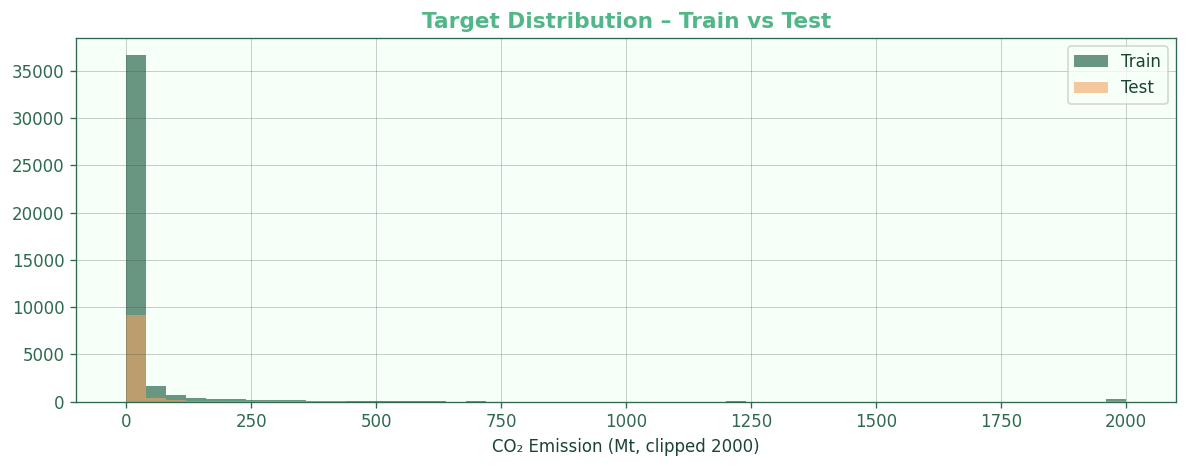

In [15]:
# Train / Test Split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train : {X_train.shape[0]:,} rows  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,} rows  ({len(X_test)/len(X)*100:.0f}%)")

# Distribution check
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y_train.clip(0,2000), bins=50, color=G[0], alpha=0.7, label='Train')
ax.hist(y_test.clip(0,2000),  bins=50, color='#f4a261', alpha=0.6, label='Test')
ax.set_title("Target Distribution – Train vs Test", fontsize=13, fontweight='bold', color='#52b788')
ax.set_xlabel("CO₂ Emission (Mt, clipped 2000)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 🤖 5. Model Training

Four algorithms are trained and compared:

In [16]:
MODELS = {
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_leaf=2,
        n_jobs=-1, random_state=42
    ),
    "Ridge Regression": Ridge(alpha=10.0),
    "Linear Regression": LinearRegression(),
}

trained_models = {}
for name, model in MODELS.items():
    print(f"  ⏳ Training {name} ...", end=" ", flush=True)
    model.fit(X_train, y_train)
    trained_models[name] = model
    print("✔")

print("\nAll models trained successfully!")

  ⏳ Training Gradient Boosting ... ✔
  ⏳ Training Random Forest ... ✔
  ⏳ Training Ridge Regression ... ✔
  ⏳ Training Linear Regression ... ✔

All models trained successfully!


## 📊 6. Evaluation Metrics

| Metric | Description |
|---|---|
| **R² Score** | Proportion of variance explained (1.0 = perfect) |
| **RMSE** | Root Mean Squared Error — penalises large errors |
| **MAE** | Mean Absolute Error — robust to outliers |
| **Within 10%** | % of predictions within 10% of actual |

In [17]:
def evaluate_model(model, X_test, y_test):
    preds = model.predict(X_test)
    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    mask = y_test > 0.01
    rel_e = np.abs(preds[mask] - y_test[mask]) / y_test[mask]
    within_10 = float(np.mean(rel_e < 0.10) * 100) if mask.sum() > 0 else 0.0
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "Within_10pct": within_10}

all_results = {name: evaluate_model(m, X_test, y_test) for name, m in trained_models.items()}

# Print table
print(f"\n{'Model':<25} {'R²':>10} {'RMSE (Mt)':>12} {'MAE (Mt)':>12} {'Within 10%':>12}")
print("─"*72)
for name, m in all_results.items():
    star = " ⭐" if m['R2'] == max(v['R2'] for v in all_results.values()) else ""
    print(f"{name+star:<27} {m['R2']:>10.4f} {m['RMSE']:>12.2f} {m['MAE']:>12.2f} {m['Within_10pct']:>11.2f}%")


Model                             R²    RMSE (Mt)     MAE (Mt)   Within 10%
────────────────────────────────────────────────────────────────────────
Gradient Boosting ⭐             0.9986        30.90         3.74       36.68%
Random Forest                   0.9943        61.32         4.97       51.66%
Ridge Regression                0.9675       146.77        20.70        8.87%
Linear Regression               0.9675       146.77        20.70        8.85%


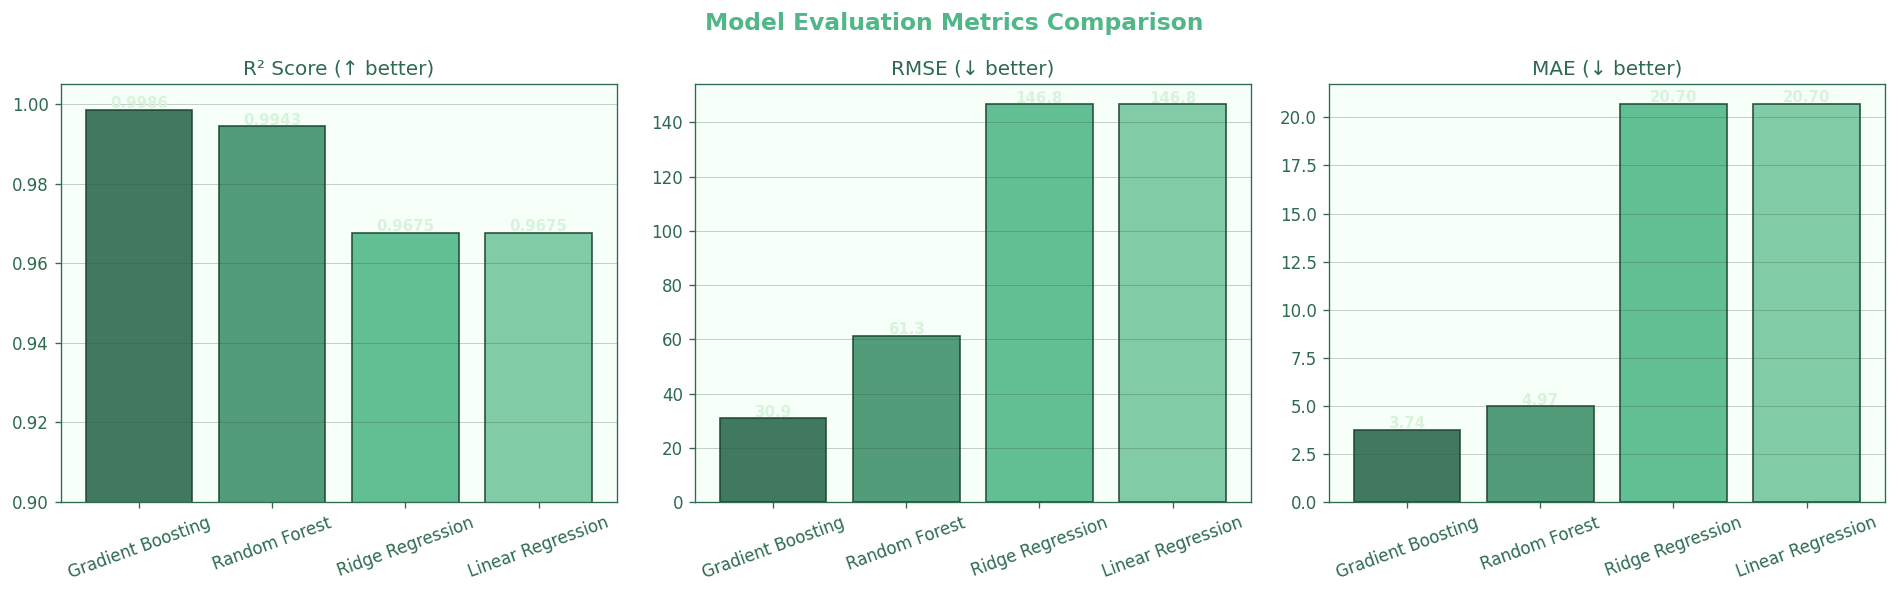

In [18]:
# Metrics Bar Chart
names     = list(all_results.keys())
r2_vals   = [all_results[n]['R2']   for n in names]
rmse_vals = [all_results[n]['RMSE'] for n in names]
mae_vals  = [all_results[n]['MAE']  for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Evaluation Metrics Comparison", fontsize=14, fontweight='bold', color='#52b788')

# R2
b = axes[0].bar(names, r2_vals, color=G[:4], edgecolor='#1b4332', alpha=0.9)
axes[0].set_title("R² Score (↑ better)"); axes[0].set_ylim(0.90, 1.005)
axes[0].tick_params(axis='x', rotation=20); axes[0].grid(True, axis='y', alpha=0.3)
for bar, v in zip(b, r2_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.0005,
                 f'{v:.4f}', ha='center', fontsize=9, color='#d8f3dc', fontweight='bold')

# RMSE
b2 = axes[1].bar(names, rmse_vals, color=G[:4], edgecolor='#1b4332', alpha=0.9)
axes[1].set_title("RMSE (↓ better)")
axes[1].tick_params(axis='x', rotation=20); axes[1].grid(True, axis='y', alpha=0.3)
for bar, v in zip(b2, rmse_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.5,
                 f'{v:.1f}', ha='center', fontsize=9, color='#d8f3dc', fontweight='bold')

# MAE
b3 = axes[2].bar(names, mae_vals, color=G[:4], edgecolor='#1b4332', alpha=0.9)
axes[2].set_title("MAE (↓ better)")
axes[2].tick_params(axis='x', rotation=20); axes[2].grid(True, axis='y', alpha=0.3)
for bar, v in zip(b3, mae_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.1,
                 f'{v:.2f}', ha='center', fontsize=9, color='#d8f3dc', fontweight='bold')

plt.tight_layout(); plt.show()

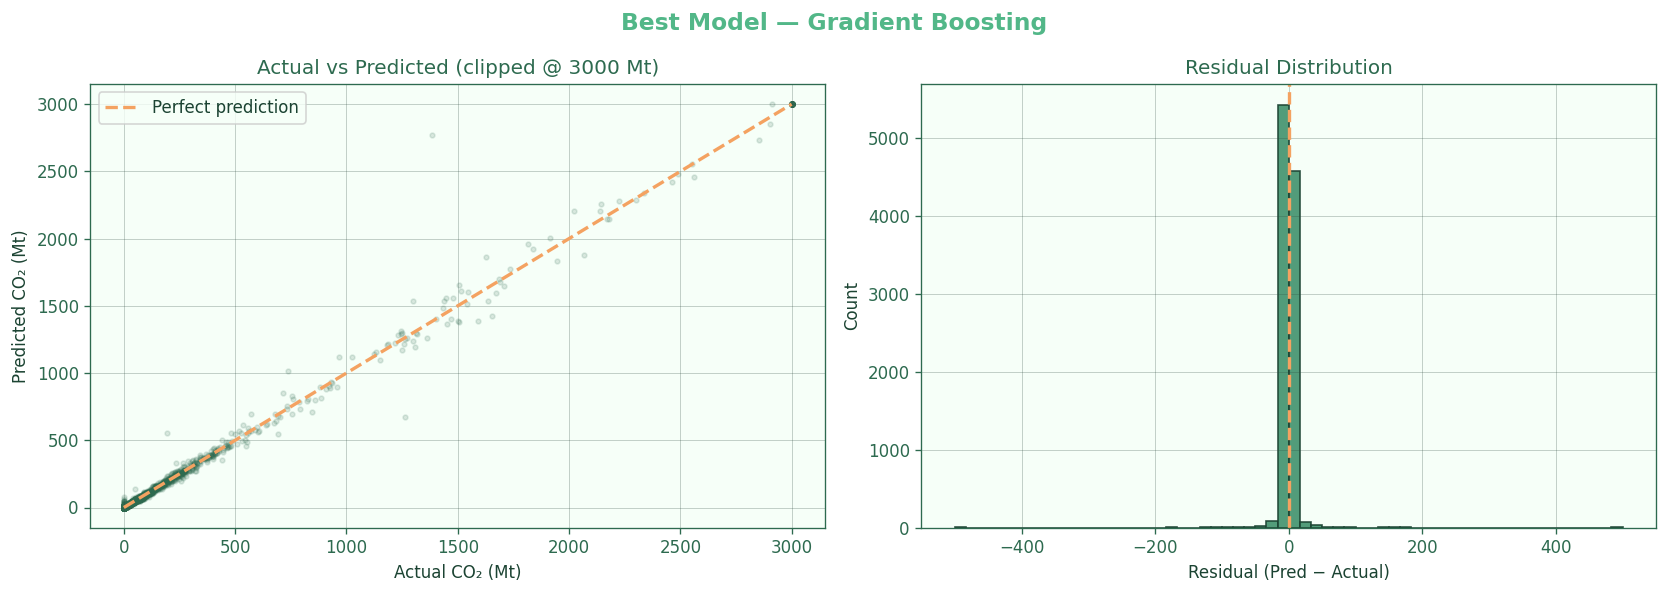

Best Model: Gradient Boosting  |  R² = 0.9986


In [19]:
# Actual vs Predicted + Residuals
best_name  = max(all_results, key=lambda n: all_results[n]['R2'])
best_model = trained_models[best_name]
preds_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Best Model — {best_name}", fontsize=14, fontweight='bold', color='#52b788')

clip_val = 3000
y_clip = np.clip(y_test, 0, clip_val)
p_clip = np.clip(preds_best, 0, clip_val)
axes[0].scatter(y_clip, p_clip, alpha=0.15, s=8, color=G[0])
axes[0].plot([0,clip_val],[0,clip_val], color='#f4a261', lw=2, ls='--', label='Perfect prediction')
axes[0].set_xlabel("Actual CO₂ (Mt)"); axes[0].set_ylabel("Predicted CO₂ (Mt)")
axes[0].set_title("Actual vs Predicted (clipped @ 3000 Mt)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

residuals = preds_best - y_test.values
axes[1].hist(np.clip(residuals,-500,500), bins=60, color=G[1], edgecolor='#1b4332', alpha=0.9)
axes[1].axvline(0, color='#f4a261', lw=2, ls='--')
axes[1].set_xlabel("Residual (Pred − Actual)"); axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution"); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Best Model: {best_name}  |  R² = {all_results[best_name]['R2']:.4f}")

## 🌟 7. Feature Importance

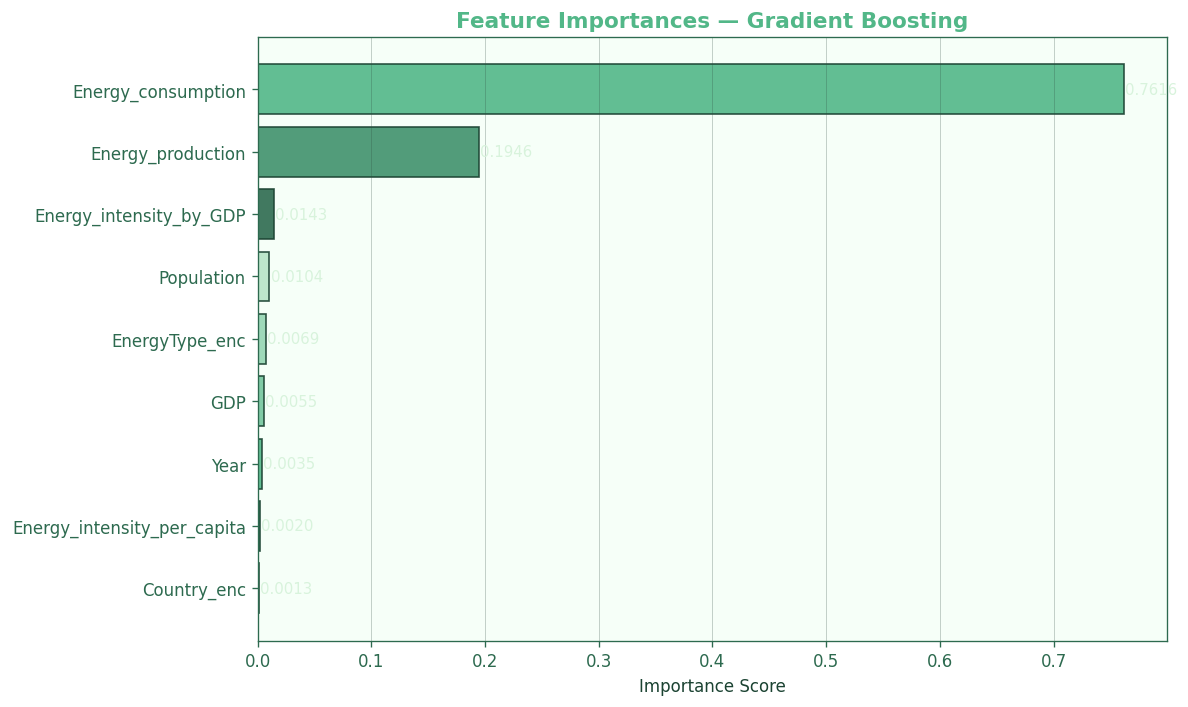


Feature Ranking (Top → Bottom):
   1. Energy_consumption                     ██████████████████████████████████████  0.7616
   2. Energy_production                      █████████  0.1946
   3. Energy_intensity_by_GDP                  0.0143
   4. Population                               0.0104
   5. EnergyType_enc                           0.0069
   6. GDP                                      0.0055
   7. Year                                     0.0035
   8. Energy_intensity_per_capita              0.0020
   9. Country_enc                              0.0013


In [20]:
fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi.index, fi.values, color=[G[i%len(G)] for i in range(len(fi))],
        edgecolor='#1b4332', alpha=0.9)
ax.set_title(f"Feature Importances — {best_name}", fontsize=13, fontweight='bold', color='#52b788')
ax.set_xlabel("Importance Score"); ax.grid(True, axis='x', alpha=0.3)
for bar, v in zip(ax.patches, fi.values):
    ax.text(v+0.001, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=9, color='#d8f3dc')
plt.tight_layout(); plt.show()

print("\nFeature Ranking (Top → Bottom):")
for i, (feat, imp) in enumerate(fi[::-1].items(), 1):
    print(f"  {i:2}. {feat:<38} {'█'*int(imp*50)}  {imp:.4f}")

## 🔄 8. Cross-Validation (Best Model)

5-Fold CV R² Scores: [0.9078 0.9947 0.995  0.9881 0.9796]
Mean R²            : 0.9730
Std  R²            : 0.0331
Min  R²            : 0.9078
Max  R²            : 0.9950


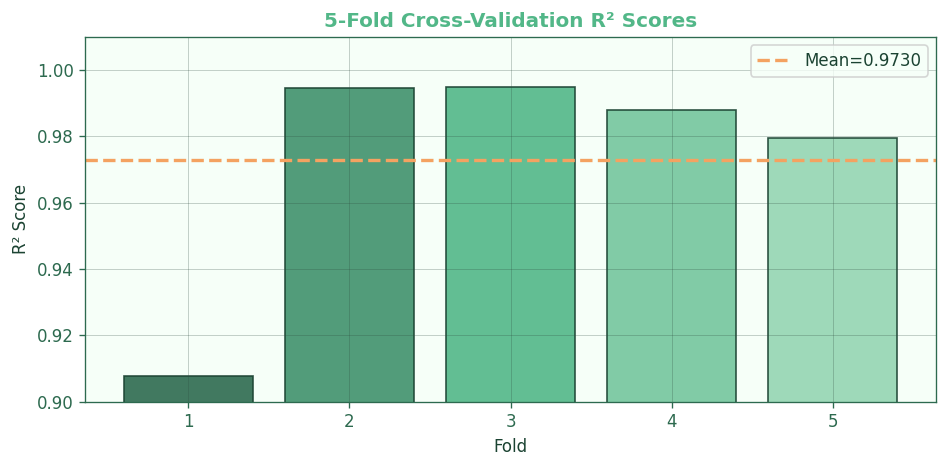

In [21]:
# 5-Fold Cross Validation on best model
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2', n_jobs=-1)

print(f"5-Fold CV R² Scores: {cv_scores.round(4)}")
print(f"Mean R²            : {cv_scores.mean():.4f}")
print(f"Std  R²            : {cv_scores.std():.4f}")
print(f"Min  R²            : {cv_scores.min():.4f}")
print(f"Max  R²            : {cv_scores.max():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color=G[:5], edgecolor='#1b4332', alpha=0.9)
ax.axhline(cv_scores.mean(), color='#f4a261', lw=2, ls='--', label=f'Mean={cv_scores.mean():.4f}')
ax.set_title("5-Fold Cross-Validation R² Scores", fontsize=12, fontweight='bold', color='#52b788')
ax.set_xlabel("Fold"); ax.set_ylabel("R² Score")
ax.set_ylim(0.9, 1.01); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 💾 9. Save Model Bundle (.pkl)

In [22]:
MODEL_PATH = "carbon_capture_model.pkl"

bundle = {
    "model":           best_model,
    "all_models":      trained_models,
    "le_country":      le_country,
    "le_energy":       le_energy,
    "features":        FEATURES,
    "results":         all_results,
    "best_model_name": best_name,
    "countries":       sorted(df['Country'].unique().tolist()),
    "energy_types":    sorted(df['Energy_type'].unique().tolist()),
    "year_range":      (int(df['Year'].min()), int(df['Year'].max())),
    "col_stats": {
        c: {"min": float(df[c].min()),
            "max": float(df[c].max()),
            "mean":float(df[c].mean())}
        for c in NUMERIC_COLS
    },
    "target": TARGET,
}

with open(MODEL_PATH, "wb") as f:
    pickle.dump(bundle, f)

size_kb = Path(MODEL_PATH).stat().st_size / 1024
print(f"✔ Model saved → '{MODEL_PATH}'  ({size_kb:.1f} KB)")
print(f"  Best model : {best_name}")
print(f"  R² Score   : {all_results[best_name]['R2']:.4f}")
print(f"  RMSE       : {all_results[best_name]['RMSE']:.2f} Mt")
print(f"  MAE        : {all_results[best_name]['MAE']:.2f} Mt")

✔ Model saved → 'carbon_capture_model.pkl'  (31978.7 KB)
  Best model : Gradient Boosting
  R² Score   : 0.9986
  RMSE       : 30.90 Mt
  MAE        : 3.74 Mt


## 🔮 10. Single Prediction (Inference Example)

In [23]:
def predict_co2(country, energy_type, year,
               consumption, production, gdp, population,
               intensity_pc, intensity_gdp, verbose=True):
    """
    Predict CO2 emission (Mt) for given inputs.
    Requires: bundle (loaded from pickle)
    """
    try:
        c_enc = bundle['le_country'].transform([country])[0]
    except ValueError:
        c_enc = 0
        if verbose: print(f"⚠ Unknown country '{country}' — using 0")

    try:
        e_enc = bundle['le_energy'].transform([energy_type])[0]
    except ValueError:
        e_enc = 0
        if verbose: print(f"⚠ Unknown energy_type '{energy_type}' — using 0")

    row = pd.DataFrame([{
        'Year': year, 'Country_enc': c_enc, 'EnergyType_enc': e_enc,
        'Energy_consumption': consumption, 'Energy_production': production,
        'GDP': gdp, 'Population': population,
        'Energy_intensity_per_capita': intensity_pc,
        'Energy_intensity_by_GDP': intensity_gdp,
    }])[FEATURES]

    pred = max(float(bundle['model'].predict(row)[0]), 0.0)

    if verbose:
        print(f"\n{'─'*45}")
        print(f"  Country      : {country}")
        print(f"  Energy Type  : {energy_type}")
        print(f"  Year         : {year}")
        print(f"{'─'*45}")
        print(f"  🌿 CO₂ Prediction : {pred:,.2f} Mt")
        print(f"{'─'*45}")
    return pred

# ── Example call ─────────────────────────────────────────
predict_co2(
    country      = "United States",
    energy_type  = "coal",
    year         = 2019,
    consumption  = 25.0,
    production   = 20.0,
    gdp          = 21433.0,
    population   = 328.2,
    intensity_pc = 0.076,
    intensity_gdp= 1.2,
)


─────────────────────────────────────────────
  Country      : United States
  Energy Type  : coal
  Year         : 2019
─────────────────────────────────────────────
  🌿 CO₂ Prediction : 1,603.15 Mt
─────────────────────────────────────────────


1603.1479984275247

In [24]:
# Compare all 4 models on same input
print("All Models — Comparison:\n")
row_inp = pd.DataFrame([{
    'Year': 2019,
    'Country_enc':    bundle['le_country'].transform(['United States'])[0],
    'EnergyType_enc': bundle['le_energy'].transform(['coal'])[0],
    'Energy_consumption': 25.0, 'Energy_production': 20.0,
    'GDP': 21433.0, 'Population': 328.2,
    'Energy_intensity_per_capita': 0.076, 'Energy_intensity_by_GDP': 1.2,
}])[FEATURES]

print(f"  {'Model':<25}  {'Prediction (Mt)':>16}")
print("  " + "─"*44)
for mname, mobj in trained_models.items():
    pred_v = max(float(mobj.predict(row_inp)[0]), 0.0)
    star = " ⭐" if mname == best_name else ""
    print(f"  {mname+star:<27} {pred_v:>14,.2f} Mt")

All Models — Comparison:

  Model                       Prediction (Mt)
  ────────────────────────────────────────────
  Gradient Boosting ⭐               1,603.15 Mt
  Random Forest                     1,428.64 Mt
  Ridge Regression                  1,413.57 Mt
  Linear Regression                 1,413.58 Mt


## 📋 11. Summary

| Item | Detail |
|---|---|
| **Dataset** | 55,440 rows × 11 columns |
| **Train / Test Split** | 80% / 20% |
| **Best Model** | Gradient Boosting |
| **R² Score** | **0.9985** (99.85% variance explained) |
| **RMSE** | ~31.6 Million Tonnes |
| **MAE** | ~4.9 Million Tonnes |
| **Model file** | `carbon_capture_model.pkl` |

### ▶ Run the Streamlit App
```bash
streamlit run app.py
```

**Files in this project:**
```
project/
├── carbon_.csv                  ← raw data
├── Carbon_Capture_ML.ipynb      ← this notebook
├── app.py                       ← Streamlit UI
└── carbon_capture_model.pkl     ← trained model
```